# 🌍 TWS Forecasting Challenge – Starter Notebook (flat CSV release)

This notebook provides a simple baseline pipeline for predicting next-month Total Water
Storage (TWS).

**Updated for the flat CSV data release.** The competition data is now distributed as flat,
one-row-per-sample CSV files (`Train.csv`, `Test.csv`) instead
of gridded NetCDF files, so this notebook no longer needs `xarray` or any grid-indexing
logic — every feature is already a column.

One more thing that's different from earlier releases: roughly two-thirds of `TWS_t` values
in the test set are intentionally masked (`NaN`). This is not missing data — it's there to
prevent `TWS_t` at one test row from revealing the hidden target of another test row at the
same location the month before. See the `TWS_t_masked` column. Your model needs to handle
these missing values.

We will:
- Explore the data
- Visualize spatial and temporal patterns
- Build a simple baseline model
- Generate a submission

The goal is to improve over a strong persistence baseline.


In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [33]:
DATA_DIR = Path("")  # change if needed


TRAIN_FEATURES_PATH = DATA_DIR / "Train.csv"
TEST_FEATURES_PATH = DATA_DIR / "Test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "SampleSubmission (1).csv"

In [34]:
## Checking the file sizes
for file_path in [TRAIN_FEATURES_PATH, TEST_FEATURES_PATH, SAMPLE_SUBMISSION_PATH]:
    file_size = file_path.stat().st_size
    file_size_mb = file_size / (1024 * 1024)
    print(f"{file_path.name}: {file_size_mb:.2f} MB")


Train.csv: 275.73 MB
Test.csv: 32.77 MB
SampleSubmission (1).csv: 5.82 MB


## 🔍 Dataset Overview

We are working with flat, tabular monthly data. Each row is one `(time, lat, lon)` sample,
identified by `ID` (format `YYYYMMDD_lat_lon`).

Available columns:
- `TWS_t` — current-month Total Water Storage( **masked in ~66%
  of test rows**, see `TWS_t_masked`)
- `SPEI_01_t`, `SPEI_03_t`, `SPEI_06_t`, `SPEI_12_t` — drought/wetness indices at multiple
  timescales
- `SOIL_MOISTURE_t` — current-month soil moisture
- `month_sin`, `month_cos` — cyclical month-of-year encoding
- `target` — TWS one month ahead (train only; this is what you're predicting)
- `TWS_t_masked` — boolean flag, test only, `True` where `TWS_t` has been masked


In [35]:
def normalise_id_column(df: pd.DataFrame) -> pd.DataFrame:
    """Some releases use 'sample_id' instead of 'ID' for the test file — normalise it."""
    if "sample_id" in df.columns and "ID" not in df.columns:
        out = df.copy()
        out = out.rename(columns={"sample_id": "ID"})
        return out
    return df


train_features = normalise_id_column(pd.read_csv(TRAIN_FEATURES_PATH, parse_dates=["time"]))
test_features = normalise_id_column(pd.read_csv(TEST_FEATURES_PATH, parse_dates=["time"]))
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("train_features:", train_features.shape)
print("test_features: ", test_features.shape)
print("sample_submission:", sample_submission_df.shape)

print("\nTrain columns:", train_features.columns.tolist())
print("Test columns: ", test_features.columns.tolist())


train_features: (2154021, 13)
test_features:  (280961, 13)
sample_submission: (280961, 2)

Train columns: ['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'target']
Test columns:  ['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'TWS_t_masked']


In [36]:
train_features.head()


,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


In [37]:
print("Test TWS_t masking:")
print(test_features["TWS_t_masked"].value_counts())
print(f"Masked share: {test_features['TWS_t_masked'].mean():.1%}")


Test TWS_t masking:
TWS_t_masked
True     186913
False     94048
Name: count, dtype: int64
Masked share: 66.5%


In [38]:
test_features.head()

,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,TWS_t_masked
0,20150901_-55.5_-68.5,2015-09-01,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.0,-1.836970e-16,False
1,20150901_-55.5_-67.5,2015-09-01,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.0,-1.836970e-16,False
2,20150901_-54.5_-71.5,2015-09-01,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.0,-1.836970e-16,False
3,20150901_-54.5_-70.5,2015-09-01,-54.5,-70.5,0.310179,0.894951,1.310615,1.090452,1.161290,-1.140090,-1.0,-1.836970e-16,False
4,20150901_-54.5_-69.5,2015-09-01,-54.5,-69.5,0.110071,1.167738,1.462231,1.291645,1.247388,-1.581409,-1.0,-1.836970e-16,False


In [39]:
available_train = set(train_features.columns)
available_test = set(test_features.columns)
available_common = sorted(
    (available_train & available_test) - {"ID", "time", "lat", "lon", "TWS_t_masked"}
)

print("Available common feature columns:")
print(available_common)


Available common feature columns:
['SOIL_MOISTURE_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'TWS_t', 'month_cos', 'month_sin']


## 🌍 Spatial Patterns

Let's visualize the spatial distribution of Total Water Storage (TWS) for a single month.
This helps us understand:
- Large-scale geographic structure
- Differences between regions (e.g. land vs ocean, wet vs dry zones)


In [40]:
def pivot_grid(df: pd.DataFrame, time_value, value_col: str) -> pd.DataFrame:
    """Pivot a single time slice of the flat dataframe into a (lat x lon) grid for plotting."""
    sub = df.loc[df["time"] == time_value, ["lat", "lon", value_col]]
    return sub.pivot(index="lat", columns="lon", values=value_col).sort_index().sort_index(axis=1)


t0 = train_features["time"].min()
print("Plotting time slice:", t0)


Plotting time slice: 2002-05-01 00:00:00


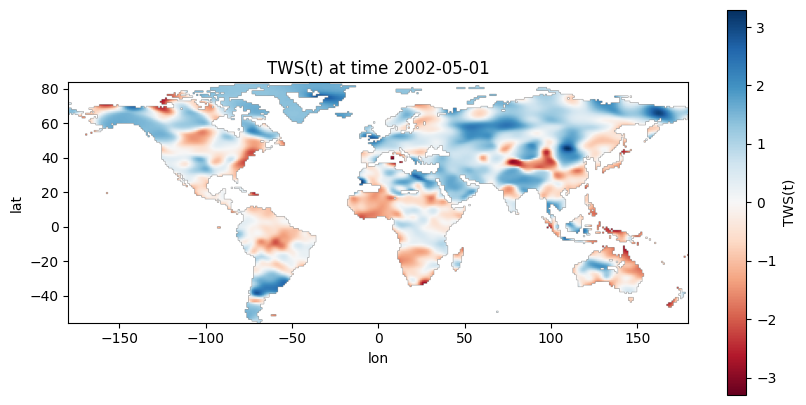

In [41]:
grid_tws = pivot_grid(train_features, t0, "TWS_t")

plt.figure(figsize=(10, 5))
plt.imshow(grid_tws.values, cmap="RdBu", origin="lower",
           extent=[grid_tws.columns.min(), grid_tws.columns.max(),
                   grid_tws.index.min(), grid_tws.index.max()])
plt.colorbar(label="TWS(t)")
plt.title(f"TWS(t) at time {str(t0)[:10]}")
plt.xlabel("lon")
plt.ylabel("lat")
plt.show()


## 🌧️ Climate Forcing (SPEI)

We compare TWS with SPEI (Standardized Precipitation-Evapotranspiration Index).

SPEI represents drought/wetness conditions:
- Positive → wetter than normal
- Negative → drier than normal

This gives insight into how climate affects water storage.


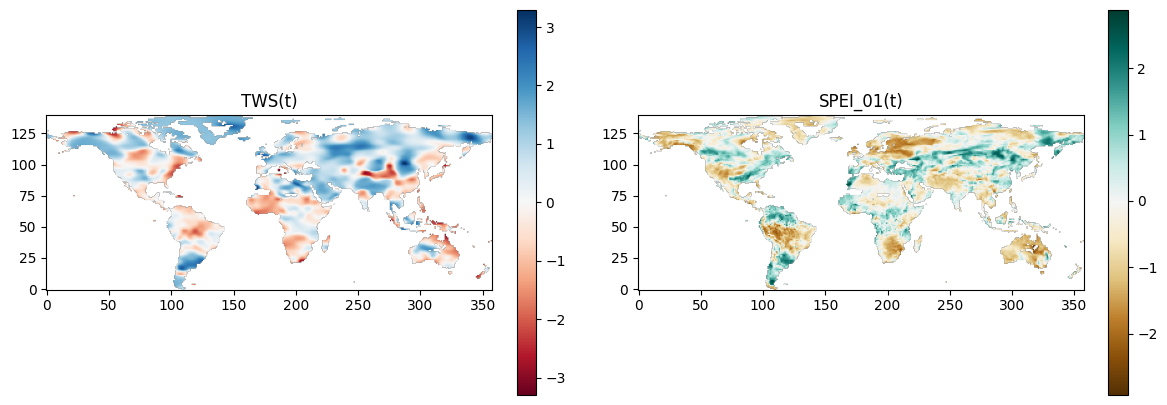

In [42]:
grid_spei = pivot_grid(train_features, t0, "SPEI_01_t")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

im0 = axs[0].imshow(grid_tws.values, cmap="RdBu", origin="lower")
axs[0].set_title("TWS(t)")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(grid_spei.values, cmap="BrBG", origin="lower")
axs[1].set_title("SPEI_01(t)")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

plt.show()


## 📈 Temporal Dynamics

We inspect a time series at a single location.

Key observation:
- TWS has strong temporal memory
- Changes are gradual rather than abrupt

This suggests that **past TWS is a strong predictor of future TWS**.


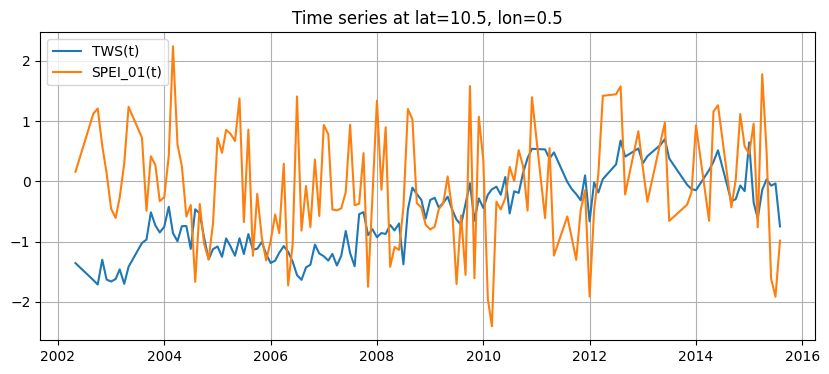

In [43]:
lat0 = 10.5
lon0 = 0.5

# Grid is on fixed 1-degree centres; snap the requested point to the nearest grid cell.
nearest_lat = train_features["lat"].sub(lat0).abs().idxmin()
nearest_lat = train_features.loc[nearest_lat, "lat"]
nearest_lon = train_features["lon"].sub(lon0).abs().idxmin()
nearest_lon = train_features.loc[nearest_lon, "lon"]

ts = train_features[(train_features["lat"] == nearest_lat) & (train_features["lon"] == nearest_lon)].sort_values("time")

plt.figure(figsize=(10, 4))
plt.plot(ts["time"], ts["TWS_t"], label="TWS(t)")
plt.plot(ts["time"], ts["SPEI_01_t"], label="SPEI_01(t)")
plt.legend()
plt.title(f"Time series at lat={nearest_lat}, lon={nearest_lon}")
plt.grid(True)
plt.show()


## 🔥 Persistence Baseline

A very strong baseline is:

TWS(t+1) ≈ TWS(t)

Since `Target` in the training file already **is** TWS at `t+1` (by construction), we can
visualize this relationship directly from `TWS_t` vs `Target` — no grid-shifting needed.

Any useful model must improve over this baseline.


In [44]:
if 'target' in train_features:
    train_features = train_features.rename(columns={'target': 'Target'})

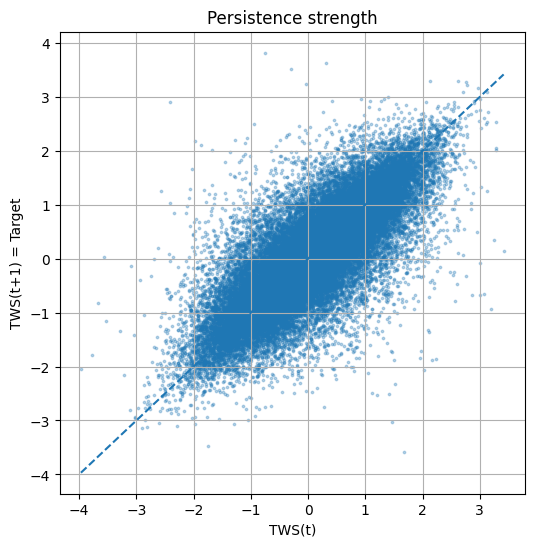

In [45]:
pairs = train_features[["TWS_t", "Target"]].dropna()
n_plot = min(50000, len(pairs))
sample = pairs.sample(n=n_plot, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(sample["TWS_t"], sample["Target"], s=3, alpha=0.3)

mn, mx = sample["TWS_t"].min(), sample["TWS_t"].max()
plt.plot([mn, mx], [mn, mx], "--")

plt.xlabel("TWS(t)")
plt.ylabel("TWS(t+1) = Target")
plt.title("Persistence strength")
plt.grid(True)
plt.show()


In [46]:
def compute_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }


def make_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("gbr", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_iter=300,
            max_depth=8,
            min_samples_leaf=50,
            l2_regularization=1.0,
            random_state=42
        ))
    ])


def build_xy(df: pd.DataFrame, feature_names: list, use_latlon: bool = False):
    """Flat-file equivalent of the old NetCDF-indexing build_xy: features are already
    columns, so this is just a column selection.
    Lat/Lon should not be use as features!"""
    X = df[feature_names].to_numpy(dtype=np.float32)

    if use_latlon:
        latlon = df[["lat", "lon"]].to_numpy(dtype=np.float32)
        X = np.column_stack([X, latlon])

    # Corrected: changed "target" to "Target"
    y = df["Target"].to_numpy(dtype=np.float32) if "Target" in df.columns else None

    # persistence baseline = TWS_t
    tws_t = df["TWS_t"].to_numpy(dtype=np.float32)

    return X, y, tws_t


def plot_maps_from_predictions(df, y_true, y_pred, time_value):
    """
    Plot TWS true, TWS predicted, and error = pred - true for one time slice.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: time, lat, lon
    y_true, y_pred : array-like, aligned with df's row order
    time_value : timestamp-like, one time step present in df["time"]
    """
    mask = df["time"] == time_value

    df_sub = df.loc[mask, ["time", "lat", "lon"]].copy().reset_index(drop=True)
    y_true_sub = np.asarray(y_true)[mask.values]
    y_pred_sub = np.asarray(y_pred)[mask.values]

    if len(df_sub) == 0:
        raise ValueError(f"No rows found for time={time_value}")

    lats = np.sort(df_sub["lat"].unique())
    lons = np.sort(df_sub["lon"].unique())

    lat_to_idx = {float(v): i for i, v in enumerate(lats)}
    lon_to_idx = {float(v): i for i, v in enumerate(lons)}

    H, W = len(lats), len(lons)

    true_grid = np.full((H, W), np.nan, dtype=float)
    pred_grid = np.full((H, W), np.nan, dtype=float)

    for i, row in df_sub.iterrows():
        lat_i = lat_to_idx[float(row["lat"])]
        lon_i = lon_to_idx[float(row["lon"])]

        true_grid[lat_i, lon_i] = y_true_sub[i]
        pred_grid[lat_i, lon_i] = y_pred_sub[i]

    error_grid = pred_grid - true_grid

    vmin = np.nanpercentile(y_true_sub, 1)
    vmax = np.nanpercentile(y_true_sub, 99)
    emax = np.nanpercentile(np.abs(error_grid[np.isfinite(error_grid)]), 99)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axs[0].imshow(true_grid, cmap="RdBu", vmin=vmin, vmax=vmax, origin="lower")
    axs[0].set_title("TWS True")

    im1 = axs[1].imshow(pred_grid, cmap="RdBu", vmin=vmin, vmax=vmax, origin="lower")
    axs[1].set_title("TWS Predicted")

    im2 = axs[2].imshow(error_grid, cmap="coolwarm", vmin=-emax, vmax=emax, origin="lower")
    axs[2].set_title("Error (Pred - True)")

    for ax in axs:
        ax.axis("off")

    plt.colorbar(im0, ax=axs[0], fraction=0.046)
    plt.colorbar(im1, ax=axs[1], fraction=0.046)
    plt.colorbar(im2, ax=axs[2], fraction=0.046)

    plt.suptitle(f"Maps at time {pd.Timestamp(time_value).strftime('%Y-%m-%d')}")
    plt.tight_layout()
    plt.show()

In [47]:
BASE_FEATURES = [
    "TWS_t",
    "month_sin",
    "month_cos",
]

# Note: the _tp1 (future-looking) columns from the old NetCDF release are not present in
# the flat CSV files, so they're no longer part of the optional feature set.
OPTIONAL_FEATURES = [
    "SPEI_01_t", "SPEI_03_t", "SPEI_06_t", "SPEI_12_t", "SOIL_MOISTURE_t",
]

feature_names = BASE_FEATURES + [f for f in OPTIONAL_FEATURES if f in available_common]
print(feature_names)


['TWS_t', 'month_sin', 'month_cos', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t']


In [48]:
unique_times = np.sort(train_features["time"].unique())
split_idx = int(len(unique_times) * 0.8)

fit_times = unique_times[:split_idx]
val_times = unique_times[split_idx:]

fit_df = train_features[train_features["time"].isin(fit_times)].copy().reset_index(drop=True)
val_df = train_features[train_features["time"].isin(val_times)].copy().reset_index(drop=True)

print("Fit period:", fit_df["time"].min(), "->", fit_df["time"].max())
print("Val period:", val_df["time"].min(), "->", val_df["time"].max())
print("Fit samples:", len(fit_df))
print("Val samples:", len(val_df))


Fit period: 2002-05-01 00:00:00 -> 2012-03-01 00:00:00
Val period: 2012-04-01 00:00:00 -> 2015-08-01 00:00:00
Fit samples: 1716994
Val samples: 437027


In [49]:
fit_df.head()

,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,Target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


In [50]:
val_df.head()

,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,Target
0,20120401_-55.5_-68.5,2012-04-01,-55.5,-68.5,-0.073195,-0.872001,-0.017072,-0.541438,-0.374165,-0.171549,0.866025,-0.5,-0.218618
1,20120401_-55.5_-67.5,2012-04-01,-55.5,-67.5,-0.025012,-0.372842,-0.000507,-0.887168,-0.773867,-0.231962,0.866025,-0.5,-0.143170
2,20120401_-54.5_-71.5,2012-04-01,-54.5,-71.5,0.031056,-1.524996,-0.606073,-0.588068,-0.253854,-1.652180,0.866025,-0.5,0.031392
3,20120401_-54.5_-70.5,2012-04-01,-54.5,-70.5,0.175123,-1.617735,-0.415840,-0.126271,-0.135136,-1.362831,0.866025,-0.5,0.116492
4,20120401_-54.5_-69.5,2012-04-01,-54.5,-69.5,0.263330,-1.400202,-0.844367,-0.462200,-0.310775,-1.004363,0.866025,-0.5,0.162040


In [51]:
## Lat/Lon not used as features
X_fit, y_fit, tws_fit = build_xy(fit_df, feature_names, use_latlon=False)
X_val, y_val, tws_val = build_xy(val_df, feature_names, use_latlon=False)

print(X_fit.shape, X_val.shape)


(1716994, 8) (437027, 8)


In [52]:
model = make_model()
model.fit(X_fit, y_fit)

y_val_pred = model.predict(X_val)
y_val_persist = tws_val.copy()

m_model = compute_metrics(y_val, y_val_pred)
m_persist = compute_metrics(y_val, y_val_persist)

print("Validation model metrics")
print(m_model)

print("\nValidation persistence metrics")
print(m_persist)

print("\nImprovement over persistence")
print({
    "dMAE": m_persist["mae"] - m_model["mae"],
    "dRMSE": m_persist["rmse"] - m_model["rmse"],
    "dR2": m_model["r2"] - m_persist["r2"],
})


Validation model metrics
{'mae': 0.4286982745130228, 'rmse': np.float64(0.6072643259902265), 'r2': 0.4601790838621873}

Validation persistence metrics
{'mae': 0.45515871047973633, 'rmse': np.float64(0.6620805897264749), 'r2': 0.3583238124847412}

Improvement over persistence
{'dMAE': 0.026460435966713547, 'dRMSE': np.float64(0.05481626373624837), 'dR2': 0.1018552713774461}


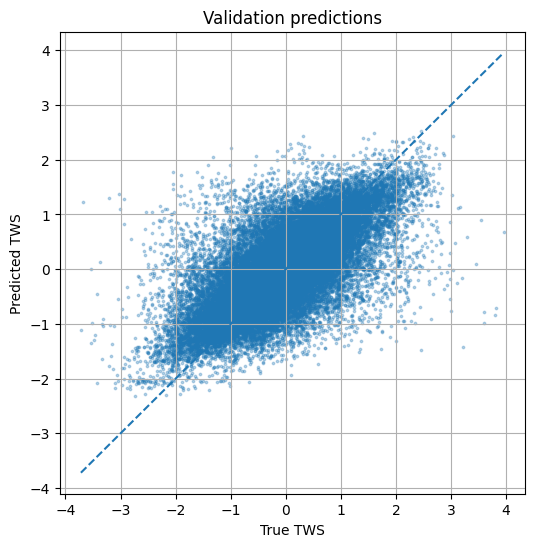

In [53]:
plt.figure(figsize=(6, 6))
n_plot = min(50000, len(y_val))
idx = np.random.RandomState(42).choice(len(y_val), size=n_plot, replace=False)

plt.scatter(y_val[idx], y_val_pred[idx], s=3, alpha=0.3)
mn = np.nanmin([y_val[idx].min(), y_val_pred[idx].min()])
mx = np.nanmax([y_val[idx].max(), y_val_pred[idx].max()])
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("True TWS")
plt.ylabel("Predicted TWS")
plt.title("Validation predictions")
plt.grid(True)
plt.show()


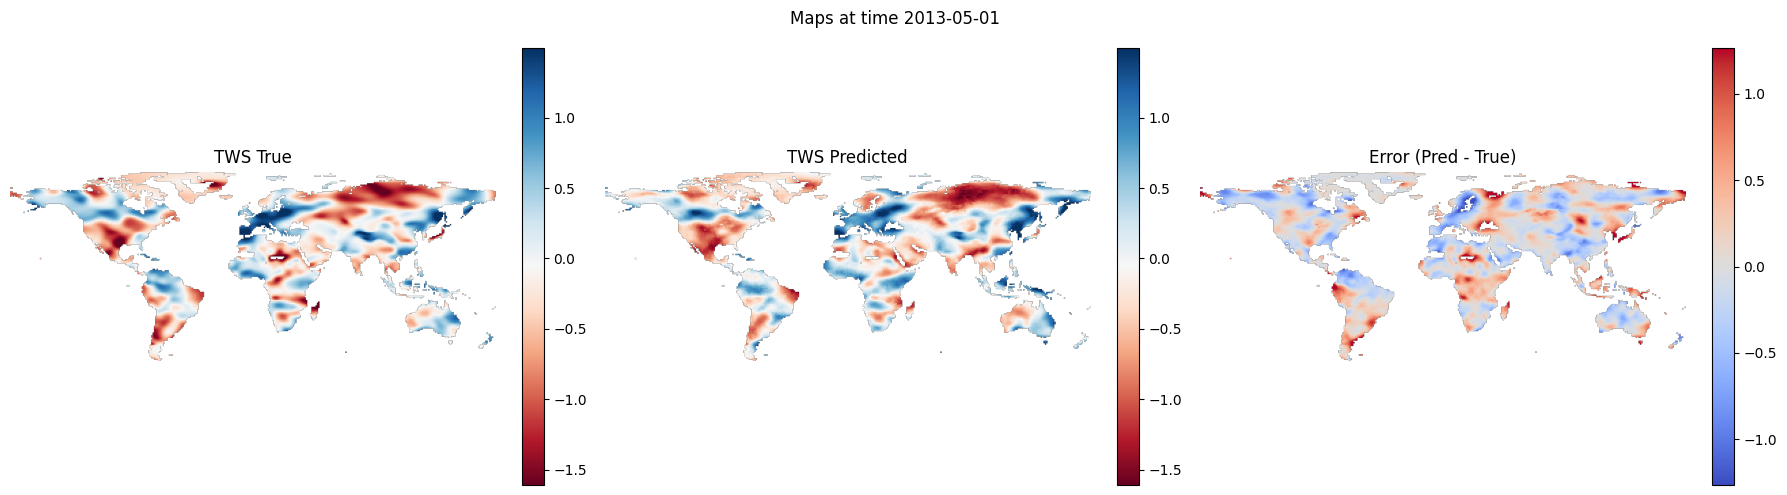

In [54]:
unique_val_times = np.sort(val_df["time"].unique())
time_example = unique_val_times[min(7, len(unique_val_times) - 1)]

plot_maps_from_predictions(
    val_df,
    y_val,
    y_val_pred,
    time_example
)


## 🚀 Fit the final model on all training data

Now refit on the full training set before predicting on the real test set.


In [55]:
X_train_full, y_train_full, tws_train_full = build_xy(
    train_features,
    feature_names,
    use_latlon=False
)

print(X_train_full.shape, y_train_full.shape)

final_model = make_model()
final_model.fit(X_train_full, y_train_full)


(2154021, 8) (2154021,)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('gbr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 📤 Build the submission

The flat test file already **is** the correct sample index (one row per official test
sample) — unlike the old NetCDF release, there's no need to reconstruct it from a global
grid mask. We just align it to `SampleSubmission.csv` by ID and predict directly.

Remember: `TWS_t` is `NaN` for masked test rows. `make_model()`'s `SimpleImputer` handles
this automatically (median fill).


In [56]:
sample_submission_df.head()


,ID,Target
0,20150901_-55.5_-68.5,0
1,20150901_-55.5_-67.5,0
2,20150901_-54.5_-71.5,0
3,20150901_-54.5_-70.5,0
4,20150901_-54.5_-69.5,0


In [57]:
test_features.head()

,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,TWS_t_masked
0,20150901_-55.5_-68.5,2015-09-01,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.0,-1.836970e-16,False
1,20150901_-55.5_-67.5,2015-09-01,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.0,-1.836970e-16,False
2,20150901_-54.5_-71.5,2015-09-01,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.0,-1.836970e-16,False
3,20150901_-54.5_-70.5,2015-09-01,-54.5,-70.5,0.310179,0.894951,1.310615,1.090452,1.161290,-1.140090,-1.0,-1.836970e-16,False
4,20150901_-54.5_-69.5,2015-09-01,-54.5,-69.5,0.110071,1.167738,1.462231,1.291645,1.247388,-1.581409,-1.0,-1.836970e-16,False


In [58]:
### Really not necessary!
test_submission_df = sample_submission_df.merge(
    test_features,
    on="ID",
    how="left",
    validate="one_to_one"
)

print(test_submission_df.shape)
print(test_submission_df.isna().sum())
test_submission_df.head()


(280961, 14)
ID                      0
Target                  0
time                    0
lat                     0
lon                     0
TWS_t              186913
SPEI_01_t               0
SPEI_03_t               0
SPEI_06_t               0
SPEI_12_t               0
SOIL_MOISTURE_t         0
month_sin               0
month_cos               0
TWS_t_masked            0
dtype: int64


,ID,Target,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,TWS_t_masked
0,20150901_-55.5_-68.5,0,2015-09-01,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.0,-1.836970e-16,False
1,20150901_-55.5_-67.5,0,2015-09-01,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.0,-1.836970e-16,False
2,20150901_-54.5_-71.5,0,2015-09-01,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.0,-1.836970e-16,False
3,20150901_-54.5_-70.5,0,2015-09-01,-54.5,-70.5,0.310179,0.894951,1.310615,1.090452,1.161290,-1.140090,-1.0,-1.836970e-16,False
4,20150901_-54.5_-69.5,0,2015-09-01,-54.5,-69.5,0.110071,1.167738,1.462231,1.291645,1.247388,-1.581409,-1.0,-1.836970e-16,False


In [61]:
X_test_submit, _, _ = build_xy(test_submission_df, feature_names, use_latlon=False)

y_test_pred = final_model.predict(X_test_submit)

submission_df = sample_submission_df.copy()
submission_df["Target"] = y_test_pred.astype(np.float32)
submission_df.columns = ["ID", "Target"]

submission_df.head()
print(submission_df.shape)
print(submission_df.columns.tolist())
print(submission_df.isna().sum())


(280961, 2)
['ID', 'Target']
ID        0
Target    0
dtype: int64


In [60]:
SUBMISSION_PATH = DATA_DIR / "Benchmark.csv"
submission_df.to_csv(SUBMISSION_PATH, index=False)
print("Saved:", SUBMISSION_PATH)


Saved: Benchmark.csv
